In [99]:
import numpy as np
import pandas as pd
import seaborn as sns


# Data Cleaning

In [100]:
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')

In [101]:
train.shape

(1460, 81)

In [102]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [103]:
train.head()
train.drop(columns=['Id'],inplace=True)
test.drop(columns=['Id'],inplace=True)

In [104]:
y = train["SalePrice"]
X = train.drop("SalePrice", axis=1)

In [105]:
Numeric = X.select_dtypes(include=['number']).columns.tolist()
Categorical = X.select_dtypes(include=['str']).columns.tolist()
Missing_value = X.columns[X.isnull().any()].tolist()

In [106]:
Missing_value

['LotFrontage',
 'Alley',
 'MasVnrType',
 'MasVnrArea',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Electrical',
 'FireplaceQu',
 'GarageType',
 'GarageYrBlt',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PoolQC',
 'Fence',
 'MiscFeature']

In [107]:
train['LotFrontage'].value_counts()

LotFrontage
60.0     143
70.0      70
80.0      69
50.0      57
75.0      53
        ... 
138.0      1
160.0      1
152.0      1
153.0      1
46.0       1
Name: count, Length: 110, dtype: int64

In [108]:
cols_none = [
'Alley','MasVnrType','BsmtQual','BsmtCond','BsmtExposure',
'BsmtFinType1','BsmtFinType2','FireplaceQu','GarageType',
'GarageFinish','GarageQual','GarageCond','PoolQC','Fence','MiscFeature'
]

train[cols_none] = train[cols_none].fillna("None")
test[cols_none] = test[cols_none].fillna("None")

In [109]:
train['LotFrontage'] = train.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

train['MasVnrArea'] = train['MasVnrArea'].fillna(0)

train['GarageYrBlt'] = train['GarageYrBlt'].fillna(0)

In [110]:
test['LotFrontage'] = test.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

test['MasVnrArea'] = test['MasVnrArea'].fillna(0)

test['GarageYrBlt'] = test['GarageYrBlt'].fillna(0)

In [111]:
train['Electrical'] = train['Electrical'].fillna(train['Electrical'].mode()[0])
test['Electrical'] = test['Electrical'].fillna(train['Electrical'].mode()[0])

In [112]:
test.isnull().sum().sort_values(ascending=False).head(20)

MSZoning        4
Utilities       2
BsmtFullBath    2
BsmtHalfBath    2
Functional      2
GarageCars      1
BsmtFinSF2      1
Exterior2nd     1
BsmtFinSF1      1
BsmtUnfSF       1
TotalBsmtSF     1
Exterior1st     1
SaleType        1
KitchenQual     1
GarageArea      1
BldgType        0
Condition2      0
Condition1      0
Neighborhood    0
LandSlope       0
dtype: int64

In [113]:
none_cols = [
'GarageType','GarageFinish','GarageQual','GarageCond',
'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2',
'FireplaceQu','PoolQC','Fence','MiscFeature','Alley'
]

test[none_cols] = test[none_cols].fillna("None")
mode_cols = [
'MSZoning','Utilities','Exterior1st','Exterior2nd',
'KitchenQual','Functional','SaleType','Electrical'
]

for col in mode_cols:
    test[col] = test[col].fillna(test[col].mode()[0])

zero_cols = [
'GarageCars','GarageArea',
'BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF',
'BsmtFullBath','BsmtHalfBath'
]

test[zero_cols] = test[zero_cols].fillna(0)
test['LotFrontage'] = test['LotFrontage'].fillna(test['LotFrontage'].median())

# Feature Construction

In [114]:
train['HouseAge'] = train['YrSold'] - train['YearBuilt']
train['RemodAge'] = train['YrSold'] - train['YearRemodAdd']
test['HouseAge'] = test['YrSold'] - test['YearBuilt']
test['RemodAge'] = test['YrSold'] - test['YearRemodAdd']

In [115]:
train['TotalSF'] = train['GrLivArea'] + train['TotalBsmtSF']
test['TotalSF'] = test['GrLivArea'] + test['TotalBsmtSF']

In [116]:
train['TotalBath'] = (
    train['FullBath'] +
    0.5 * train['HalfBath'] +
    train['BsmtFullBath'] +
    0.5 * train['BsmtHalfBath']
)

test['TotalBath'] = (
    test['FullBath'] +
    0.5 * test['HalfBath'] +
    test['BsmtFullBath'] +
    0.5 * test['BsmtHalfBath']
)

In [117]:
train['TotalPorchSF'] = (
    train['WoodDeckSF'] +
    train['OpenPorchSF'] +
    train['EnclosedPorch'] +
    train['3SsnPorch'] +
    train['ScreenPorch']
)

test['TotalPorchSF'] = (
    test['WoodDeckSF'] +
    test['OpenPorchSF'] +
    test['EnclosedPorch'] +
    test['3SsnPorch'] +
    test['ScreenPorch']
)

In [118]:
train['OverallScore'] = train['OverallQual'] * train['OverallCond']
test['OverallScore'] = test['OverallQual'] * test['OverallCond']

In [119]:
for df in [train, test]:
    df['HasPool'] = (df['PoolArea'] > 0).astype(int)
    df['HasGarage'] = (df['GarageArea'] > 0).astype(int)
    df['HasFireplace'] = (df['Fireplaces'] > 0).astype(int)
    df['HasBasement'] = (df['TotalBsmtSF'] > 0).astype(int)

<Axes: xlabel='SalePrice', ylabel='Density'>

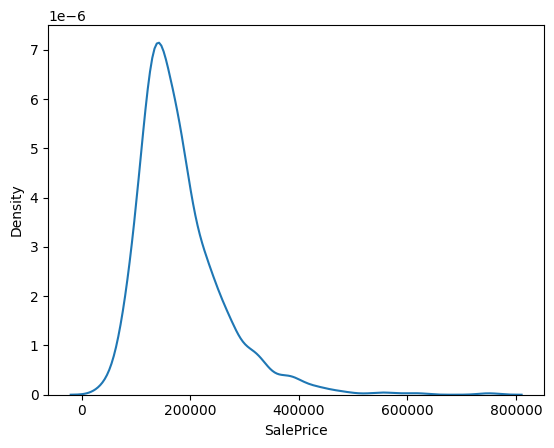

In [120]:
sns.kdeplot(train['SalePrice'])

In [121]:
y = np.log1p(train['SalePrice'])

# MOdeling

In [122]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor


from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [123]:
models = {
    'LinearRegression' : LinearRegression(),
    'RandomForestRegressor':RandomForestRegressor(),
    'SVR':SVR(),
    'KNeighborsRegressor':KNeighborsRegressor()    
}

In [124]:
Lr = LinearRegression()
rf = RandomForestRegressor(random_state=42)
svr = SVR(max_iter=100)
knn = KNeighborsRegressor(n_neighbors=5)

In [125]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [137]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns


num_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])


X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)


C:\Users\Mayank saini\AppData\Local\Temp\ipykernel_31512\1499813966.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X_train.select_dtypes(include=['object', 'category']).columns


In [129]:

X_train_scaled = pd.DataFrame(X_train_scaled).fillna(pd.DataFrame(X_train_scaled).median()).values
X_test_scaled = pd.DataFrame(X_test_scaled).fillna(pd.DataFrame(X_test_scaled).median()).values


In [130]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    print(
        f"{name}: "
        f"{r2_score(y_test, y_pred):.4f}"
    )

LinearRegression: 0.9064
RandomForestRegressor: 0.8842
SVR: 0.8767
KNeighborsRegressor: 0.8171


In [ ]:

predictions = models["LinearRegression"].predict(X_test_scaled)


In [138]:
test_original = pd.read_csv('data/test.csv')

test_scaled = preprocessor.transform(test_original[X_train.columns])
test_scaled = pd.DataFrame(test_scaled).fillna(pd.DataFrame(test_scaled).median()).values


predictions = models["LinearRegression"].predict(test_scaled)


submission = pd.DataFrame({
    'Id': test_original['Id'],
    'SalePrice': np.expm1(predictions)  # ← don't forget to reverse log1p!
})
submission.to_csv('data/submission.csv', index=False)

In [136]:
print("Predictions count:", len(predictions))
print("Test IDs count:", len(test_original))


Predictions count: 292
Test IDs count: 1459
